# 知识蒸馏

> 一个好老师不只给标准答案，还会解释思路、在学生犯错时及时纠正。大模型和小模型之间的关系也类似——与其让小模型自己摸索，不如让大模型「教」它。
>
> 这一节理解蒸馏的三种方法：Logit-based（学输出分布）、Feature-based（学中间表示）、On-Policy（大模型实时批改），并走通从大模型蒸馏到小模型的完整流程。

在 LLM 上下文中，Teacher 是能力更强的模型（可以是闭源 API、大开源模型或同模型的增强版本），Student 是目标部署模型。传统做法是让 Teacher 写出标准答案，Student 照着学习。

但 Student 在背熟 Teacher 的输出之后，一旦独立生成，质量就会下降。原因在于 Student 的训练数据和它自己生成时的数据分布不同，这个差异称为分布偏移（distribution shift）。

最先出现也最经典的方法是 Logit-based 蒸馏——让 Student 不只学答案，还学 Teacher 对每个词的概率判断。

## 1. 蒸馏的本质

```
普通 SFT（监督微调）:
  Teacher 输出: "巴黎"
  Student 学习: 输入"法国首都是？" → 输出"巴黎"
  问题: 只学了答案，没学推理过程

蒸馏:
  Teacher 输出: 每个词的概率分布 [巴黎:0.9, 伦敦:0.05, 柏林:0.03, ...]
  Student 学习: 不仅输出"巴黎"，还要让整个概率分布接近 Teacher
  好处: Student 学到了 Teacher 的「判断力」——知道"巴黎"最可能，"伦敦"也有可能但概率低
```

**为什么概率分布比答案更有价值？**

Teacher 说「巴黎 90%，伦敦 5%，柏林 3%」比只说「巴黎」多了两条信息：
1. 伦敦和柏林也是合理的（只是不太对）——这叫「暗知识」
2. 其他几百个城市概率接近 0——明确告诉 Student 哪些是错的

这就是 Hinton 等人在知识蒸馏中强调的“软目标/暗知识”直觉。参考：[Distilling the Knowledge in a Neural Network](https://arxiv.org/abs/1503.02531)。

In [1]:
import numpy as np

# 硬标签 vs 软标签：用真实概率分布对比
print("=== 硬标签 vs 软标签 ===")
print()

cities = ["巴黎", "伦敦", "柏林", "罗马", "马德里", "东京", "北京", "悉尼"]
teacher_logits = np.array([5.0, 2.0, 1.0, 0.5, 0.1, -3.0, -4.0, -5.0])

# 硬标签 (SFT): one-hot，只在正确答案位置为 1
hard_labels = np.zeros(len(cities))
hard_labels[0] = 1.0

print("问题：法国的首都是？")
print()
print("硬标签 (SFT)：")
for city, prob in zip(cities[:5], hard_labels[:5]):
    bar = "█" * int(prob * 40)
    print(f"  {city}: {prob:.1%} {bar}")
print("  Student 只知道「巴黎是对的」，其他全部归零")
print()

# 软标签 (蒸馏)：用温度 T 软化 logits 后做 softmax
temperature = 3.0
scaled_logits = teacher_logits / temperature
soft_labels = np.exp(scaled_logits) / np.exp(scaled_logits).sum()

print(f"软标签 (蒸馏, T={temperature:.0f})：")
for city, prob in zip(cities, soft_labels):
    bar = "█" * int(prob * 40)
    print(f"  {city}: {prob:.1%} {bar}")
print("  Student 学到了：")
print("    1. 巴黎最对（高概率）")
print("    2. 伦敦、柏林也是欧洲首都（相似性知识）")
print("    3. 东京、北京概率接近 0（明确排除）")
print()

# 量化信息量差异：信息熵
hard_entropy = -np.sum(hard_labels * np.log(hard_labels + 1e-10))
soft_entropy = -np.sum(soft_labels * np.log(soft_labels + 1e-10))
print(f"硬标签信息熵：{hard_entropy:.2f} bits")
print(f"软标签信息熵：{soft_entropy:.2f} bits")
print(f"软标签携带的额外信息量约 {soft_entropy:.2f} bits，硬标签接近 0")


=== 硬标签 vs 软标签 ===

问题：法国的首都是？

硬标签 (SFT)：
  巴黎: 100.0% ████████████████████████████████████████
  伦敦: 0.0% 
  柏林: 0.0% 
  罗马: 0.0% 
  马德里: 0.0% 
  Student 只知道「巴黎是对的」，其他全部归零

软标签 (蒸馏, T=3)：
  巴黎: 45.4% ██████████████████
  伦敦: 16.7% ██████
  柏林: 12.0% ████
  罗马: 10.1% ████
  马德里: 8.9% ███
  东京: 3.2% █
  北京: 2.3% 
  悉尼: 1.6% 
  Student 学到了：
    1. 巴黎最对（高概率）
    2. 伦敦、柏林也是欧洲首都（相似性知识）
    3. 东京、北京概率接近 0（明确排除）

硬标签信息熵：-0.00 bits
软标签信息熵：1.62 bits
软标签携带的额外信息量约 1.62 bits，硬标签接近 0


## 2. 方法一：Logit 蒸馏（最经典）

让 Student 的输出概率分布逼近 Teacher 的输出概率分布。

**Loss 公式**：

$$L = (1-\alpha) \cdot L_{CE}(S, y) + \alpha \cdot T^2 \cdot L_{KL}(S_T, T_T)$$

其中：
- $L_{CE}$：Student 和正确答案的交叉熵（保证基本正确）
- $L_{KL}$：Student 和 Teacher 概率分布的 KL 散度（学习暗知识）
- $T$：温度参数，越大 Teacher 的分布越「软」（暗知识越明显）
- $\alpha$：平衡两个 loss 的权重

**温度 T 的作用**：
```
T=1:  [0.90, 0.05, 0.03, 0.02]  ← 很尖锐，暗知识不明显
T=5:  [0.40, 0.25, 0.20, 0.15]  ← 软化了，暗知识浮现
T=20: [0.28, 0.26, 0.24, 0.22]  ← 太软了，变成均匀分布
```

T 太大 → 所有词概率差不多 → 没信息量
T 太小 → 和硬标签没区别 → 没暗知识
T=3~10 是常见实验起点，不是固定规则；不同任务、模型和 loss 权重要通过验证集调整。

In [2]:
import numpy as np

# 温度 T 对软标签的影响
print("=== 温度 T 对软标签的影响 ===")
print()

logits = np.array([5.0, 2.0, 1.0, 0.5, 0.1, 0.01, 0.001, 0.0001])
labels = ["巴黎", "伦敦", "柏林", "罗马", "马德里", "维也纳", "布拉格", "华沙"]

for T in [1, 3, 10, 20]:
    scaled = logits / T
    probs = np.exp(scaled) / np.exp(scaled).sum()

    print(f"T={T:2d}: ", end="")
    for i in range(5):
        bar = "█" * int(probs[i] * 50)
        print(f"{labels[i]}:{probs[i]:.3f} {bar}  ", end="")
    print()

print()
print("T=1：几乎只有巴黎，暗知识被掩盖")
print("T=3：伦敦、柏林浮现出来，暗知识开始显现")
print("T=10：分布更均匀，暗知识丰富但正确答案的信号变弱")
print("T=20：接近均匀分布，信息量太少")


=== 温度 T 对软标签的影响 ===

T= 1: 巴黎:0.903 █████████████████████████████████████████████  伦敦:0.045 ██  柏林:0.017   罗马:0.010   马德里:0.007   
T= 3: 巴黎:0.382 ███████████████████  伦敦:0.141 ███████  柏林:0.101 █████  罗马:0.085 ████  马德里:0.075 ███  
T=10: 巴黎:0.182 █████████  伦敦:0.135 ██████  柏林:0.122 ██████  罗马:0.116 █████  马德里:0.112 █████  
T=20: 巴黎:0.152 ███████  伦敦:0.130 ██████  柏林:0.124 ██████  罗马:0.121 ██████  马德里:0.119 █████  

T=1：几乎只有巴黎，暗知识被掩盖
T=3：伦敦、柏林浮现出来，暗知识开始显现
T=10：分布更均匀，暗知识丰富但正确答案的信号变弱
T=20：接近均匀分布，信息量太少


## 3. 方法二：数据蒸馏（最容易落地）

直接做 full-vocab logit 蒸馏时，Student 和 Teacher 最好共享 tokenizer 或能建立可靠的跨 tokenizer 对齐；闭源 API 通常拿不到完整 logits，所以 LLM 场景里更常见的是数据蒸馏或只用 top-k / sampled-token 近似信号。

**数据蒸馏绕过了这个问题**：让 Teacher 生成训练数据，Student 在这些数据上做 SFT。

```
Step 1: 收集 prompts（从你的业务场景中）
  ["写一首关于春天的诗", "解释量子力学", "翻译: Hello → 中文", ...]

Step 2: Teacher 为每个 prompt 生成高质量回答
  GPT-4: "春天来了，万物复苏..."
  GPT-4: "量子力学是研究微观粒子..."

Step 3: 用 (prompt, teacher_answer) 对训练 Student
  Student 做标准 SFT，学习模仿 Teacher 的输出风格和质量
```

**优点**：不要求词表相同，任何 Teacher 可以教任何 Student。
**缺点**：只学到了「答案长什么样」，没学到「概率分布中的暗知识」。

**数据蒸馏的进阶技巧**：
- **多轮对话蒸馏**：Teacher 生成多轮对话，Student 学会对话节奏
- **CoT 蒸馏**：Teacher 生成带推理过程的答案，Student 学会推理
- **拒绝采样**：Teacher 生成多个答案，只保留最好的给 Student 学

In [3]:
# 数据蒸馏流程模拟：Teacher 生成训练数据，Student 在其上做 SFT
print("=== 数据蒸馏流程 ===")
print()

prompts = [
    "解释什么是机器学习",
    "写一首关于秋天的五言诗",
    "Python 中 list 和 tuple 的区别",
]

# 模拟 Teacher (GPT-4) 的回答
teacher_responses = [
    "机器学习是人工智能的一个分支，让计算机从数据中学习模式，而不需要显式编程。",
    "秋风扫落叶，霜降百花残。独坐寒窗下，思君衣可单。",
    "list 是可变的（可以增删改），tuple 是不可变的（创建后不能修改）。list 用 []，tuple 用 ()。",
]

print("Step 1：收集 prompts，Step 2：Teacher 生成回答")
for i, (prompt, response) in enumerate(zip(prompts, teacher_responses)):
    print(f"\n--- 样本 {i+1} ---")
    print(f"User: {prompt}")
    print(f"Assistant: {response}")

print()
print(f"Step 3：把 {len(prompts)} 条 (prompt, teacher_answer) 作为 SFT 训练数据")
print("数据量级：几千条可跑通概念；生产效果通常需要更多高质量、多样化样本")
print("具体数量取决于任务宽度、teacher 质量和 student 基座能力，通过验证集决定是否继续扩充")


=== 数据蒸馏流程 ===

Step 1：收集 prompts，Step 2：Teacher 生成回答

--- 样本 1 ---
User: 解释什么是机器学习
Assistant: 机器学习是人工智能的一个分支，让计算机从数据中学习模式，而不需要显式编程。

--- 样本 2 ---
User: 写一首关于秋天的五言诗
Assistant: 秋风扫落叶，霜降百花残。独坐寒窗下，思君衣可单。

--- 样本 3 ---
User: Python 中 list 和 tuple 的区别
Assistant: list 是可变的（可以增删改），tuple 是不可变的（创建后不能修改）。list 用 []，tuple 用 ()。

Step 3：把 3 条 (prompt, teacher_answer) 作为 SFT 训练数据
数据量级：几千条可跑通概念；生产效果通常需要更多高质量、多样化样本
具体数量取决于任务宽度、teacher 质量和 student 基座能力，通过验证集决定是否继续扩充


## 4. 方法三：特征蒸馏（进阶）

不仅学输出分布，还学中间层的表示。

```
Teacher (GPT-4, 96层):
  Layer 1 → Layer 2 → ... → Layer 48 → ... → Layer 96 → Output
                                      ↑
Student (7B, 32层):                  |  让 Student 第 16 层的输出
  Layer 1 → Layer 2 → ... → Layer 16 → ... → Layer 32 → Output  逼近 Teacher 第 48 层
```

**为什么有效？** 中间层包含了「怎么理解这句话」的信息，比最终输出更丰富。

**为什么少用？**
- 需要访问 Teacher 的内部表示（闭源模型不行）
- Teacher 和 Student 的维度不同，需要投影矩阵对齐
- 计算量大，显存消耗高

在闭源 teacher + 开源 student 的 LLM 场景里，数据蒸馏最容易落地；特征蒸馏更多用于能访问 teacher hidden states 的白盒设置，视觉模型和小型语言模型中都能看到类似思路。

## 5. 实战：蒸馏 7B 模型

前面讲了三种蒸馏方法的原理，现在把它们串成一次完整的蒸馏流程。整个过程分为四步：

1. **准备训练数据**：收集一批高质量的 prompt，覆盖目标领域——数学推理、代码生成、或者通用对话
2. **Teacher 生成**：用强 teacher 模型为每个 prompt 生成回答；具体模型和价格会随时间变化，保存为 (prompt, teacher_answer) 对
3. **Student 训练**：如果能拿到 teacher logits，可用 KL 做 logit 蒸馏；如果只能拿到文本回答，就用 SFT 做数据蒸馏
4. **评估对比**：用评测 benchmark 对比 Student 在蒸馏前后的分数变化

下面每一步都给出可执行的代码。即使没有真正的 GPT-4 API key，也可以用本地的 MiniGPT 来模拟 Teacher 和 Student 的角色，完整跑通流程。

蒸馏流程的六个步骤：

1. **选基座模型**：Qwen2.5-7B / Llama-3-8B / Mistral-7B 等。基座模型本身要有一定能力，通常选 Instruct 版本（已经会遵循指令）。
2. **收集 prompts**：业务数据、开源数据集（OpenHermes、ShareGPT、WildChat）、或用另一个 LLM 生成多样化 prompt。先小规模验证数据质量，再按验证集收益扩充。
3. **Teacher 生成回答**：用 GPT-4 API 为每个 prompt 生成回答，system prompt 设定 Teacher 角色，temperature=0.7 保留一定多样性。成本按当日 API 价格、输入/输出 token、重试率和过滤率估算。
4. **数据清洗**：去掉过短（<20 token）的回答、包含「作为 AI」等拒绝回答、格式错乱、以及相似度 >0.9 的重复。
5. **SFT 训练**：用 LLaMA-Factory、Axolotl、Firefly 等工具，ChatML 或 ShareGPT 格式；常见起点 lr=2e-5, epochs=3, batch_size=128。硬件消耗取决于模型大小、LoRA/全参、序列长度和优化器策略。
6. **评测**：用 lm-eval 跑标准 benchmark，人工评估业务数据，对比 Student 和 Teacher 的差距。

## 6. 蒸馏与 OPD 对比

| 维度 | 数据蒸馏 | OPD（On-Policy Distillation） |
|:---|:---|:---|
| **Teacher 参与时机** | 训练前（生成数据） | 训练中（实时打分） |
| **Student 训练数据** | Teacher 写的标准答案 | Student 自己写的答案 |
| **工程复杂度** | 低（就是 SFT） | 高（需要 rollout + 实时 Teacher） |
| **Exposure Bias** | 可能存在（训练 prefix 多来自 teacher/数据集） | 会缓解（在 student 当前 prefix 上训练），但不保证完全消除 |
| **词表要求** | 文本级数据蒸馏无要求 | logit/token 级 OPD 需要同 tokenizer 或跨 tokenizer 对齐；黑盒反馈可绕开部分限制 |
| **成本** | 低（Teacher 只跑一次） | 高（Teacher 每次训练迭代都跑） |
| **适用场景** | 快速原型、预算有限 | 追求极致性能、有工程团队 |

**建议**：先用数据蒸馏快速出一个版本，效果好就上线；如果效果不够，再考虑 OPD。

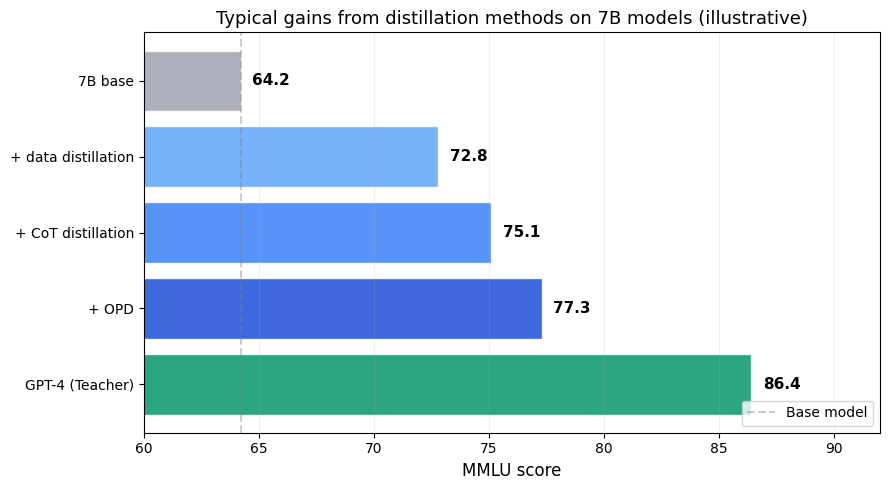

示意量级：数据蒸馏通常提升 5-10 分，CoT 蒸馏再叠加 1-3 分，OPD 边际收益递减。
具体增益取决于 teacher 选择、数据质量、训练超参和评测配置。


In [4]:
# 蒸馏方法的典型效果对比（基于公开技术报告的量级，仅作示意）
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = "DejaVu Sans"

# 示例分数：取公开报告中 7B 模型在 MMLU 上的典型量级
data = [
    ("7B base", 64.2, "#9CA3AF"),
    ("+ data distillation", 72.8, "#60A5FA"),
    ("+ CoT distillation", 75.1, "#3B82F6"),
    ("+ OPD", 77.3, "#1D4ED8"),
    ("GPT-4 (Teacher)", 86.4, "#059669"),
]
names = [d[0] for d in data]
scores = [d[1] for d in data]
colors = [d[2] for d in data]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(names, scores, color=colors, alpha=0.85, edgecolor="white")
for bar, score in zip(bars, scores):
    ax.text(score + 0.5, bar.get_y() + bar.get_height()/2, f"{score:.1f}",
            va="center", fontsize=11, fontweight="bold")

ax.axvline(64.2, color="gray", linestyle="--", alpha=0.4, label="Base model")
ax.set_xlabel("MMLU score", fontsize=12)
ax.set_title("Typical gains from distillation methods on 7B models (illustrative)", fontsize=13)
ax.set_xlim(60, 92)
ax.grid(axis="x", alpha=0.2)
ax.invert_yaxis()
ax.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

print("示意量级：数据蒸馏通常提升 5-10 分，CoT 蒸馏再叠加 1-3 分，OPD 边际收益递减。")
print("具体增益取决于 teacher 选择、数据质量、训练超参和评测配置。")


## 7. 蒸馏的常见问题

| 问题 | 答案 |
|:---|:---|
| **Student 能超过 Teacher 吗？** | 不应把 Teacher 当成绝对上限。Student 可能因为更适合某个任务、更干净的数据、更强解码/工具或额外训练，在局部 benchmark 上超过某个 teacher；但通常难以全面复制 teacher 的能力。 |
| **蒸馏会丢失什么？** | 创造性、长尾知识、复杂推理——这些是 Teacher 的「暗知识」中最难蒸馏的部分 |
| **需要多少数据？** | 没有固定最少条数。先用小规模验证数据质量和训练链路，再按验证集收益扩充；数据质量、覆盖面和去重往往比单纯数量更关键。 |
| **Teacher 和 Student 词表不同怎么办？** | 用数据蒸馏（方法二），不要求词表相同 |
| **蒸馏后还需要 RLHF 吗？** | 看场景。蒸馏会继承一部分 teacher 的风格和安全行为，但不能保证完整对齐；仍需要安全评测、拒答边界和业务数据验证。 |
| **多 Teacher 蒸馏可行吗？** | 可以。多 teacher 可以按任务取长补短，但需要处理风格冲突、许可证/数据政策和质量过滤；“综合能力更强”必须用评测验证。 |

## 小结

- [ ] **蒸馏本质**：学 Teacher 的概率分布（暗知识），而不只是标准答案
- [ ] **Logit 蒸馏**：让 Student 的输出分布逼近 Teacher，需要同词表
- [ ] **数据蒸馏**：Teacher 生成训练数据，Student 做 SFT，最容易落地
- [ ] **特征蒸馏**：学中间层表示，适合白盒 teacher；效果取决于层对齐和任务
- [ ] **实战流程**：选基座 → 收集 prompt → Teacher 生成 → 清洗 → SFT → 评测
- [ ] **蒸馏与 OPD**：数据蒸馏容易落地，OPD 可能更贴近 student 真实生成分布但成本和复杂度更高
- [ ] **CoT 蒸馏**：让 Teacher 生成带推理过程的答案，Student 学会推理

**一句话总结**：蒸馏 = 让大模型当老师，小模型当学生。最容易落地的方法是数据蒸馏：让强 teacher 生成高质量样本，小模型通过 SFT 学习；样本量、teacher 选择和成本都要按项目重新估算。

## 作业

> 可以让 AI 帮忙解释思路、拆解步骤、检查方向，但不建议直接让 AI 「做完这道题」。

**作业 1：温度对软标签的影响**

知识蒸馏中，温度 $T$ 用于软化 Teacher 的输出分布：$p_i = \frac{e^{z_i/T}}{\sum_j e^{z_j/T}}$。给定 Teacher 对三个词的 logits：$[4.0, 2.0, 1.0]$。分别计算 $T=1$ 和 $T=5$ 时的概率分布。

<details><summary>小提示</summary>$T=1$ 时分布尖锐（概率集中在最大值），$T=5$ 时分布平坦（暗知识更明显）。</details>

In [5]:
# 作业 1：温度对软标签的影响
import math

logits = [4.0, 2.0, 1.0]


def softmax_with_temp(logits, T):
    exps = [math.exp(l / T) for l in logits]
    total = sum(exps)
    return [e / total for e in exps]


# TODO: 计算 T=1 时的概率分布
probs_T1 = softmax_with_temp(logits, 1)

# TODO: 计算 T=5 时的概率分布
probs_T5 = softmax_with_temp(logits, 5)

assert probs_T1 is not None, "请先计算 T=1 的概率"
assert probs_T5 is not None, "请先计算 T=5 的概率"

expected_T1 = softmax_with_temp(logits, 1)
expected_T5 = softmax_with_temp(logits, 5)

for i, (p, e) in enumerate(zip(probs_T1, expected_T1)):
    assert abs(p - e) < 0.01, f"T=1 时 p[{i}] 应为 {e:.4f}"

for i, (p, e) in enumerate(zip(probs_T5, expected_T5)):
    assert abs(p - e) < 0.01, f"T=5 时 p[{i}] 应为 {e:.4f}"

dk_T1 = probs_T1[1] / probs_T1[2]
dk_T5 = probs_T5[1] / probs_T5[2]

print("作业 1 通过：")
print(f"   T=1: {probs_T1} → 概率集中在最大值")
print(f"   T=5: {probs_T5} → 概率更均匀，暗知识更明显")
print(f"   暗知识比值（次大/最小）: T=1={dk_T1:.2f}, T=5={dk_T5:.2f}")
print("   温度越高，非正确答案的概率差异越清晰——这就是暗知识。")


作业 1 通过：
   T=1: [0.8437947344813395, 0.11419519938459449, 0.04201006613406605] → 概率集中在最大值
   T=5: [0.4506267059556897, 0.3020641142811064, 0.24730917976320382] → 概率更均匀，暗知识更明显
   暗知识比值（次大/最小）: T=1=2.72, T=5=1.22
   温度越高，非正确答案的概率差异越清晰——这就是暗知识。


**作业 2：KL 散度手算**

KL 散度衡量两个分布的差异：$D_{KL}(P \| Q) = \sum_i P_i \log \frac{P_i}{Q_i}$。假设 Teacher 分布 $P = [0.7, 0.2, 0.1]$，Student 分布 $Q = [0.5, 0.3, 0.2]$。手动计算 KL 散度。

<details><summary>小提示</summary>$D_{KL} = 0.7 \times \log(0.7/0.5) + 0.2 \times \log(0.2/0.3) + 0.1 \times \log(0.1/0.2)$。</details>

In [6]:
# 作业 2：KL 散度手算
import math

P = [0.7, 0.2, 0.1]
Q = [0.5, 0.3, 0.2]

# TODO: 计算 KL 散度 D_KL(P || Q)
kl_div = sum(p * math.log(p / q) for p, q in zip(P, Q))

assert kl_div is not None, "请先计算 KL 散度"

expected = sum(p * math.log(p / q) for p, q in zip(P, Q))
assert abs(kl_div - expected) < 0.01, f"KL 散度应为 {expected:.4f}，你得到 {kl_div:.4f}"

print("作业 2 通过：")
print(f"   Teacher: {P}")
print(f"   Student: {Q}")
print(f"   KL(P||Q) = {kl_div:.4f}")
print("   KL 散度 ≥ 0，等于 0 当且仅当两个分布完全相同。")
print("   蒸馏的目标就是最小化 Student 和 Teacher 之间的 KL 散度。")


作业 2 通过：
   Teacher: [0.7, 0.2, 0.1]
   Student: [0.5, 0.3, 0.2]
   KL(P||Q) = 0.0851
   KL 散度 ≥ 0，等于 0 当且仅当两个分布完全相同。
   蒸馏的目标就是最小化 Student 和 Teacher 之间的 KL 散度。


**作业 3：三种蒸馏方法对比**

| 方法 | 需要 Teacher 在线参与 | 训练数据来源 | 工程复杂度 |
|:---|:---|:---|:---|
| Logit 蒸馏 | 是 | 原始数据集 | 中 |
| 数据蒸馏 | 否（离线） | Teacher 生成的数据 | 低 |
| 特征蒸馏 | 是 | 原始数据集 | 高 |

场景：团队有 70B Teacher 和 7B Student，训练资源有限（4 张 A100）。应该选择哪种蒸馏方法？

<details><summary>小提示</summary>资源有限 → 优先选择工程复杂度低、不需要 Teacher 实时参与的方案。</details>

In [7]:
# 作业 3：三种蒸馏方法对比
answer = "B"
# A) Logit 蒸馏
# B) 数据蒸馏
# C) 特征蒸馏

assert not answer.startswith("在这里"), "请先填入你的答案"
assert answer in "ABC", "请填入 A/B/C 中的一个字母"

if answer == "B":
    print("作业 3 通过：")
    print("   资源有限场景下，数据蒸馏是最务实的选择：")
    print("   1. Teacher 离线生成数据，不需要训练时实时调用")
    print("   2. Student 端等价于 SFT，工程实现简单")
    print("   3. 只需跑一次 Teacher 推理，后续训练不需要 Teacher")
    print("   4. 4 张 A100 足够完成 7B 模型的 SFT 训练")
else:
    reasons = {
        "A": "Logit 蒸馏需要 Teacher 在线参与，每步都要调用，成本更高。",
        "C": "特征蒸馏需要访问中间层输出，工程复杂度最高。",
    }
    print(f"你选了 {answer}。{reasons.get(answer, '')}")
    print("提示：资源有限 → 选最简单、不需要 Teacher 实时参与的方案。")


作业 3 通过：
   资源有限场景下，数据蒸馏是最务实的选择：
   1. Teacher 离线生成数据，不需要训练时实时调用
   2. Student 端等价于 SFT，工程实现简单
   3. 只需跑一次 Teacher 推理，后续训练不需要 Teacher
   4. 4 张 A100 足够完成 7B 模型的 SFT 训练
